## Newton's Method for Normal Distributions Transforms

This notebook walks through the optimization method employed by the normal distribution transform.

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import plotting as plot
import mat_ops as mat
import MeshSampler as ms
import plotly.graph_objects as go

from copy import copy
from typing import Callable, cast

#### Newton's method in 1-D

To find the minimum of the function, $f(x)$, we would simply compute $f'(x) = 0$. If $x$ cannot be isolated in $f'(x)$, however, solving for the minima requires an iterative method. An example is a curve with the equation:

\begin{align*}
f(x) = x^2 + e^{-x}
\end{align*}

whose derivative is

\begin{align*}
f'(x) = 2x - e^{-x}
\end{align*}

These functions are defined and plotted below.

C:\Users\user\AppData\Local\Temp\ipykernel_28104\2121208960.py:7: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



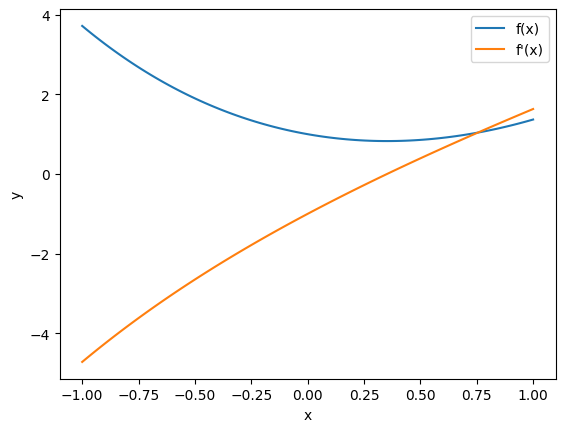

In [21]:
def f( x: float ) -> float:
    return x ** 2 + np.exp( -x )

def f_d( x: float ) -> float:
    return 2 * x - np.exp( -x )

plot.plot_univariate_functions( funcs = [f, f_d], labels = ['f(x)', "f'(x)"], x_range = (-1, 1) ).show()

To first show gradient descent in action, we'll start with a derivate for which the local minima is easily found, $f(x) = ( x - 2 )^2$. The minima can be found by setting the derivative equal to $0$, $f'(x) = 2 ( x - 2 ) = 2x - 4 = 0 \rightarrow x = 2$. This can be confirmed visually in the plot below.

C:\Users\user\AppData\Local\Temp\ipykernel_28104\3186809734.py:4: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



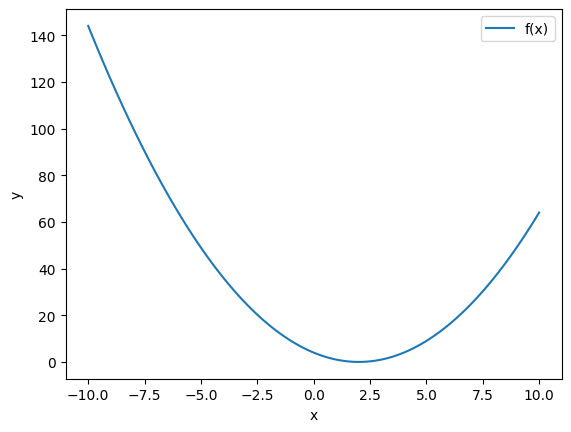

In [22]:
def f( x: float ) -> float:
    return ( x - 2 ) ** 2

plot.plot_univariate_functions( funcs = [f], labels = ['f(x)'], x_range = (-10, 10) ).show()

If it were not so easy to determine the value of $x$ where $f'(x) = 0$, we could use Newton's method to iteratively find the minima. Let's say we had an initial guess that $f'(-2) = 0$. Our initial guess, $x_n = -2$, could then be improved by computing $x_{n + 1} = x_n - \alpha d_k$, where $\alpha$ is the learning rate (or step size) in the direction of $d_k$, which is the direction of descent toward the minima. Since the derivative $f'(x)$ represents the tangent line of $f(x)$ at any given $x$, we can simply set $d_k = f'(x)$. Thus, the iterative equation is then $x_{n + 1} = x_n - \alpha f'(x_n)$. Below are examples solving the iterative method with a termination criteria of $\epsilon < 0.001$, meaning that the algorithm stops when $| \Delta f(x) | = | f(x_{n + 1}) - f(x_n) | < 0.001$.

C:\Users\user\AppData\Local\Temp\ipykernel_28104\1448738240.py:34: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



Minima found at x = 1.98548811776


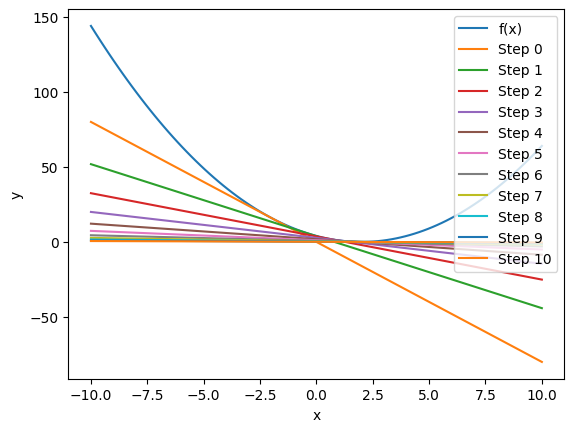

In [23]:
def gradient_descent_1d_func_gen( f: Callable[[float], float], f_d: Callable[[float], float], x_0: float, learning_rate: float = 0.2, epsilon: float = 0.001 ) -> list[Callable[[float], float]]:
    
    delta_f: float = epsilon * 10
    x: float = x_0

    f_n: list[Callable[[float], float]] = [f]
    
    while( delta_f > epsilon ):
        m = f_d( x )
        b = f( x ) - m * x

        f_n.append( lambda x_n, m = m, b = b: m * x_n + b )

        f_xn_1 = f( x )
        x = x - learning_rate * f_d( x )
        f_xn = f( x)

        delta_f = abs( f_xn - f_xn_1 )

    print( f"Minima found at x = {x}" )

    return f_n

def f( x: float ) -> float:
    return ( x - 2 ) ** 2

def f_d( x: float ) -> float:
    return  2 * ( x - 2 )

plottable_funcs = gradient_descent_1d_func_gen( f = f, f_d = f_d, x_0 = -2 )
labels = [f"Step {l - 1}" for l, _ in enumerate(plottable_funcs) ]
labels[0] = "f(x)"

plot.plot_univariate_functions( funcs = plottable_funcs, labels = labels, x_range = (-10, 10) ).show()

As shown, the algorithm above computed $x = 1.985$, near to the analytical value found at $x = 2$. A smaller $\epsilon$ (and potentially smaller $\alpha$ to avoid overshooting), would yield an even more accurate result. Using the example above of a function for which finding the analytical solution is not practical, $f(x) = x^2 + e^{-x}$, gradient descent works just as well.

Minima found at x = 0.3636200610598141


C:\Users\user\AppData\Local\Temp\ipykernel_28104\1225739881.py:11: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



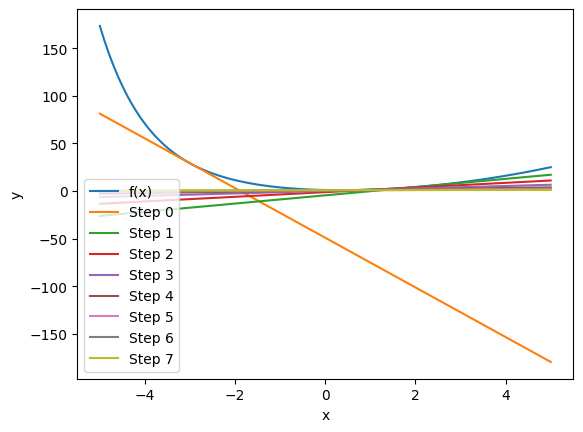

In [24]:
def f( x: float ) -> float:
    return x ** 2 + np.exp( -x )

def f_d( x: float ) -> float:
    return  2 * x - np.exp( -x )

plottable_funcs = gradient_descent_1d_func_gen( f = f, f_d = f_d, x_0 = -3, learning_rate = 0.2 )
labels = [f"Step {l - 1}" for l, _ in enumerate(plottable_funcs) ]
labels[0] = "f(x)"

plot.plot_univariate_functions( funcs = plottable_funcs, labels = labels, x_range = (-5, 5) ).show()

Unfornately, the last example shows the sensitivity of the algorithm to $\alpha$. Gradient descent can be seen overshooting the solution in step 1, then backtracking to find the minima at $x = 0.364$. To mitigate this, Newton's Method exploits the curvature information contained in $f''(x)$ to set the value of $\alpha$. The equation for Newton's Method is

\begin{align*}
x_{n + 1} = x_n - f''(x)^{-1} f'(x)
\end{align*}

In a simple example, such as $f(x) = x^2$, $f''(x) = 2$, meaning that the ideal learning rate for a simple parabola is $2^{-1} = 0.5$. A plot with this higher learning rate is shown below.

Minima found at x = 2.0


C:\Users\user\AppData\Local\Temp\ipykernel_28104\975835239.py:37: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



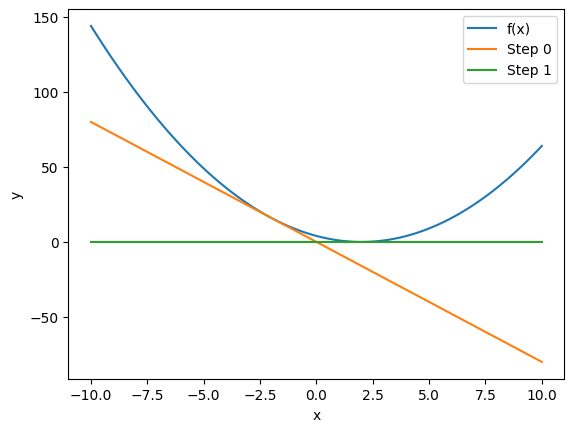

In [25]:
def newtons_method_1d_func_gen( f: Callable[[float], float], f_d: Callable[[float], float], f_dd: Callable[[float], float], x_0: float, epsilon: float = 0.001 ) -> list[Callable[[float], float]]:
    
    delta_f: float = epsilon * 10
    x: float = x_0

    f_n: list[Callable[[float], float]] = [f]
    
    while( delta_f > epsilon ):
        m = f_d( x )
        b = f( x ) - m * x

        f_n.append( lambda x_n, m = m, b = b: m * x_n + b )

        f_xn_1 = f( x )
        x = x - f_d( x ) / f_dd( x )
        f_xn = f( x)

        delta_f = abs( f_xn - f_xn_1 )

    print( f"Minima found at x = {x}" )

    return f_n

def f( x: float ) -> float:
    return ( x - 2 ) ** 2

def f_d( x: float ) -> float:
    return  2 * ( x - 2 )

def f_dd( x: float ) -> float:
    return 2

plottable_funcs = newtons_method_1d_func_gen( f = f, f_d = f_d, f_dd = f_dd, x_0 = -2 )
labels = [f"Step {l - 1}" for l, _ in enumerate(plottable_funcs) ]
labels[0] = "f(x)"

plot.plot_univariate_functions( funcs = plottable_funcs, labels = labels, x_range = (-10, 10) ).show()

Compared to our guess of $\alpha = 0.2$ using gradient descent, Newton's Method solved for the minima perfectly in 1 iteration. Shown below on $f(x) = x^2 + e^{-x}$, Newton's Method solved for the minima in 3 steps (rather than 7, above), and converged without overshooting.

Minima found at x = 0.35172483870686516


C:\Users\user\AppData\Local\Temp\ipykernel_28104\2979069093.py:14: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



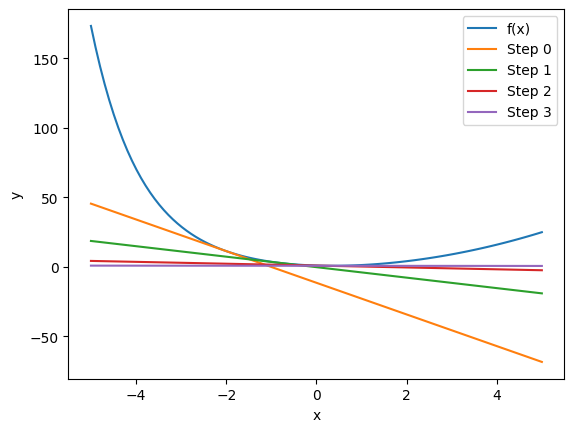

In [26]:
def f( x: float ) -> float:
    return x ** 2 + np.exp( -x )

def f_d( x: float ) -> float:
    return  2 * x - np.exp( -x )

def f_dd( x: float ) -> float:
    return 2 + np.exp( -x )

plottable_funcs = newtons_method_1d_func_gen( f = f, f_d = f_d, f_dd = f_dd, x_0 = -2 )
labels = [f"Step {l - 1}" for l, _ in enumerate(plottable_funcs) ]
labels[0] = "f(x)"

plot.plot_univariate_functions( funcs = plottable_funcs, labels = labels, x_range = (-5, 5) ).show()

Extending this to a multivariate problem, the code below shows Newton's method for a classic "bowl" problem in 2 dimensions, centered at $( 2, -5 )$. The equation becomes $f(x_1, x_2) = ( x_1 - 2 )^2 + ( x_2 + 5 )^2 = x_1^2 - 4 x_1 + 4 + x_2^2 + 10 x_2 + 25 = x_1^2 + x_2^2 - 4 x_1 + 10 x_2 + 4 + 25$. In matrix form, the equation is:

\begin{align*}
f(x_1, x_2) = \begin{bmatrix} x_1 & x_2 \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} + \begin{bmatrix} -4 & 10 \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} + \begin{bmatrix} 4 & 25 \end{bmatrix} \begin{bmatrix} 1 \\ 1 \end{bmatrix}
\end{align*}

and we are now solving the problem $\vec{x}_{n + 1} = \vec{x}_n - \nabla^2 f(\vec{x})^{-1} \nabla f(\vec{x}) = \vec{x}_{n + 1} = \vec{x}_n - H^{-1} J$.

Computing the Jacobian (first derivative), which should have the dimensions of $outputs \times inputs$, yields:

\begin{align*}
J = \begin{bmatrix} \frac{\delta f}{\delta x_1} & \frac{\delta f}{\delta x_2} \end{bmatrix} = \begin{bmatrix} 2 x_1 - 4 & 2 x_2 + 10 \end{bmatrix}
\end{align*}

Finally, computing the Hessian yields:

\begin{align*}
H = \begin{bmatrix} \frac{\delta^2 f}{\delta x_1} & \frac{\delta^2 f}{\delta x_1 x_2} \\ \frac{\delta^2 f}{\delta x_2 x_1} & \frac{\delta^2 f}{\delta x_2} \end{bmatrix} = \begin{bmatrix} 2 & 0 \\ 0 & 2 \end{bmatrix}
\end{align*}

The above equation is a positive definite - i.e. the Eigenvalues are positive and non-zero. This means that the function defines a "bowl"-shape and is solvable as a minimization function. Other options include:

**Positive definite:** All Eigenvalues are positive. Each dimension converges to a minima.

**Negative definite:** All Eigenvalues are negative. Each dimension converges to a maxima.

**Indefinite:** Some Eigenvalues are positive and some are negative. In the 2D case, this defines a saddle.

**Positive semi-definite:** All Eigenvalues are either positive or zero, making the matrix rank-deficient and non-invertable.

**Negative semi-definite:** All Eigenvalues are either negative or zero, making the matrix rank-deficient and non-invertable.


Critical point found at x = [ 2. -5.]


C:\Users\user\AppData\Local\Temp\ipykernel_28104\3588410837.py:39: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



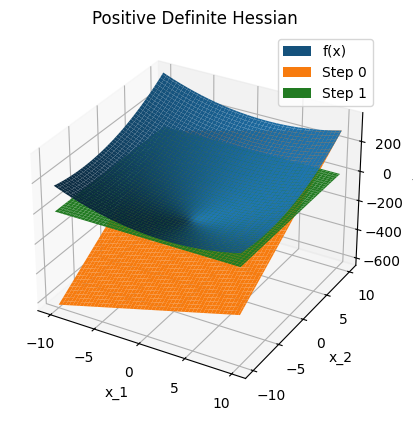

In [27]:
def newtons_method_2d_func_gen( f: Callable[[float, float], float], f_d: Callable[[float, float], np.ndarray], f_dd: Callable[[float, float], np.ndarray], x_0: np.ndarray, epsilon: float = 0.001, max_iterations: int = 10 ) -> list[Callable[[float, float], float]]:
    
    delta_f: float = epsilon * 10
    iterations: int = max_iterations
    x: np.ndarray = x_0

    f_n: list[Callable[[float, float], float]] = [f]
    
    while( delta_f > epsilon and iterations > 0 ):
        grad = f_d( x[0], x[1] )
        c = f( x[0], x[1] ) - ( grad[0] * x[0] + grad[1] * x[1] ) 

        f_n.append( lambda x_n1, x_n2, a = grad[0], b = grad[1], c = c: float( a * x_n1 + b * x_n2 + c ) )

        f_xn_1 = f( x[0], x[1] )
        x = x - np.linalg.inv( f_dd( x[0], x[1] ) ) @ f_d( x[0], x[1] )
        f_xn = f( x[0], x[1] )

        delta_f = abs( f_xn - f_xn_1 )
        iterations -= 1

    print( f"Critical point found at x = {x}" )

    return f_n

def f( x1: float, x2: float ) -> float:
    return ( x1 - 2 ) ** 2 + ( x2 + 5 ) ** 2

def f_d( x1: float, x2: float ) -> np.ndarray:
    return np.array( [2 * x1 - 4, 2 * x2 + 10] )

def f_dd( x1: float, x2: float ) -> np.ndarray:
    return np.array( [[2, 0], [0, 2]] )

plottable_funcs = newtons_method_2d_func_gen( f = f, f_d = f_d, f_dd = f_dd, x_0 = np.array( [10, 10] ) )
labels = [f"Step {l - 1}" for l, _ in enumerate(plottable_funcs) ]
labels[0] = "f(x)"

plot.plot_multivariate_functions( funcs = plottable_funcs, labels = labels, x_range = (-10, 10), title = "Positive Definite Hessian" ).show()

Below are examples of cost surfaces for each of the non-positive definite Hessian that will lead to instability when using Newton's Method.

**Negative Definite**

\begin{align*}
f(x_1, x_2) = -x_1^2 - x_2^2
\end{align*}

\begin{align*}
J = \begin{bmatrix} \frac{\delta f}{\delta x_1} & \frac{\delta f}{\delta x_2} \end{bmatrix} = \begin{bmatrix} -2x_1 & -2x_2 \end{bmatrix}
\end{align*}

\begin{align*}
H = \begin{bmatrix} \frac{\delta^2 f}{\delta x_1} & \frac{\delta^2 f}{\delta x_1 x_2} \\ \frac{\delta^2 f}{\delta x_2 x_1} & \frac{\delta^2 f}{\delta x_2} \end{bmatrix} = \begin{bmatrix} -2 & 0 \\ 0 & -2 \end{bmatrix}
\end{align*}

This example shows how Newton's method easily adapts to find the only critical point available - a local maxima. This works since the Hessian practically negates the learning rate-term, causing the algorithm to climb rather than descend. This is important for problems where the cost surface is "bumpy" (multiple local critical points) and the cost must be minimized (as in NDT). The solution to this to dampen the Hessian term via $(H + \lambda I)^{-1}$ which, when give an appropriately large $\lambda$, slides the Eigenvalues until a positive definite is produced. This "dampens" the algorithm by decreasing the learning rate. The Levenberg-Marquardt algorithm does this dynamically, where the algorithm begins in a highly-damped phase (closer to gradient descent) before slowly morphing into pure Newton's Method by decreasing $\lambda \rightarrow 0$.

Critical point found at x = [0. 0.]


C:\Users\user\AppData\Local\Temp\ipykernel_28104\1642063956.py:14: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



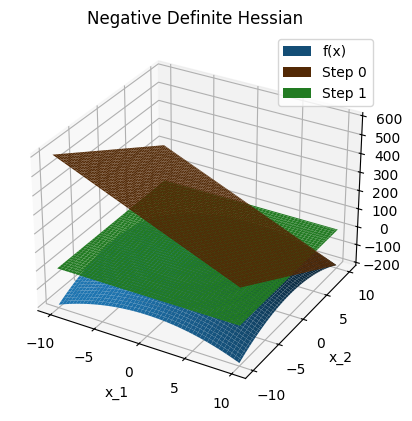

In [28]:
def f( x1: float, x2: float ) -> float:
    return -x1 ** 2 - x2 ** 2

def f_d( x1: float, x2: float ) -> np.ndarray:
    return np.array( [-2 * x1, -2 * x2] )

def f_dd( x1: float, x2: float ) -> np.ndarray:
    return np.array( [[-2, 0], [0, -2]] )

plottable_funcs = newtons_method_2d_func_gen( f = f, f_d = f_d, f_dd = f_dd, x_0 = np.array( [10, 10] ) )
labels = [f"Step {l - 1}" for l, _ in enumerate(plottable_funcs) ]
labels[0] = "f(x)"

plot.plot_multivariate_functions( funcs = plottable_funcs, labels = labels, x_range = (-10, 10), title = "Negative Definite Hessian" ).show()

**Levenberg Marquardt**

In the example $f(x_1, x_2) = x_1^3 - 3x + x_2^2 - 3x$, if the initial guess were near $(0, 0)$ there are four critical points that Newton's Method could converge to - a maxima, minima, and two saddles. Using pure Newton's Method, the initialization is critical to finding the local minima at $(1, 1)$. Given:

\begin{align*}
J = \begin{bmatrix} \frac{\delta f}{\delta x_1} & \frac{\delta f}{\delta x_2} \end{bmatrix} = \begin{bmatrix} 3x_1^2 - 3 & 3x_2^2 - 3 \end{bmatrix}
\end{align*}

\begin{align*}
H = \begin{bmatrix} \frac{\delta^2 f}{\delta x_1} & \frac{\delta^2 f}{\delta x_1 x_2} \\ \frac{\delta^2 f}{\delta x_2 x_1} & \frac{\delta^2 f}{\delta x_2} \end{bmatrix} = \begin{bmatrix} 6x_1 & 0 \\ 0 & 6x_2 \end{bmatrix}
\end{align*}

we can see that any initialization where $(x_1, x_2)$ are not both positive will result in convergence onto either a saddle point or the local maxima at $(-1, -1)$. Though extending $(x_1, x_2)$ beyond $(-1, -1)$ will result in divergence down the slope in the negative direction, the area for which convergence on the local minima can be guaranteed can be extended using the Levenberg-Marquardt algorithm. If we initialize with $\lambda = 0.001$ in the slightly negative region, the algorithm will begin climbing the hill toward the local maxima. To punish the algorithm for attempting to move up the hill by continually increasing $\lambda$ by a factor of $10$, the algorithm will eventually (once $\lambda = 1$, in this case) converge on the local minima at $(1, 1)$. This works up until intializiation reaches the local maxima at $(-1, -1)$, where the convergence becomes unstable via the "ball on the hill" problem. 

C:\Users\user\AppData\Local\Temp\ipykernel_28104\2791608357.py:4: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



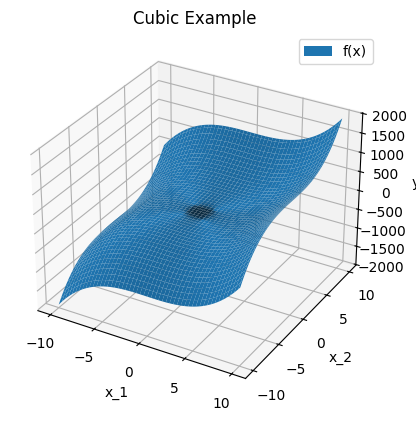

In [29]:
def f( x1: float, x2: float ) -> float:
    return x1 ** 3 - 3 * x1 + x2 ** 3 - 3 * x2

plot.plot_multivariate_functions( funcs = [f], labels = ["f(x)"], x_range = (-10, 10), title = "Cubic Example" ).show()

Critical point found at x = [-1.00000005 -1.00000005]


C:\Users\user\AppData\Local\Temp\ipykernel_28104\1011257017.py:14: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



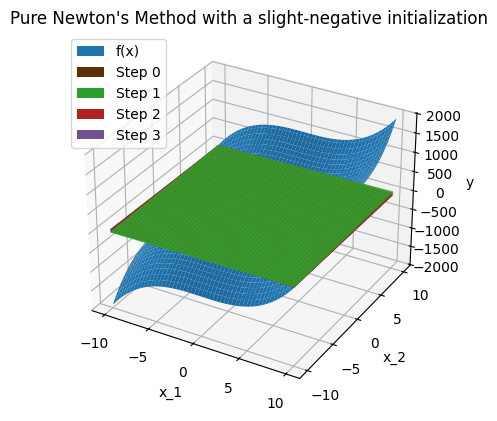

In [30]:
def f( x1: float, x2: float ) -> float:
    return x1 ** 3 - 3 * x1 + x2 ** 3 - 3 * x2

def f_d( x1: float, x2: float ) -> np.ndarray:
    return np.array( [3 * x1 ** 2 - 3, 3 * x2 ** 2 - 3] )

def f_dd( x1: float, x2: float ) -> np.ndarray:
    return np.array( [[6 * x1, 0], [0, 6 * x2]] )

plottable_funcs = newtons_method_2d_func_gen( f = f, f_d = f_d, f_dd = f_dd, x_0 = np.array( [-0.5, -0.5] ) )
labels = [f"Step {l - 1}" for l, _ in enumerate(plottable_funcs) ]
labels[0] = "f(x)"

plot.plot_multivariate_functions( funcs = plottable_funcs, labels = labels, x_range = (-10, 10), title = "Pure Newton's Method with a slight-negative initialization" ).show()

Step 0 / 10:  Score increased - increasing lambda to 0.01 to reverse direction.
Step 0 / 10:  Score increased - increasing lambda to 0.1 to reverse direction.
Step 0 / 10:  Score increased - increasing lambda to 1.0 to reverse direction.
Step 1 / 10:  Score decreased - decreasing lambda to 0.1 to speed up progress toward the minima.
Step 2 / 10:  Score decreased - decreasing lambda to 0.01 to speed up progress toward the minima.
Critical point found at x = [1. 1.]


C:\Users\user\AppData\Local\Temp\ipykernel_28104\236031824.py:49: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



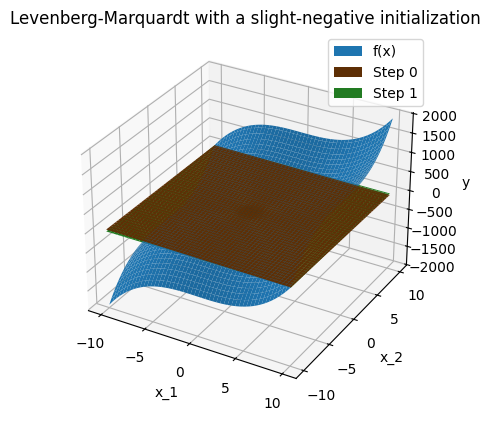

In [31]:
def levenberg_marquardt_2d_func_gen( f: Callable[[float, float], float], f_d: Callable[[float, float], np.ndarray], f_dd: Callable[[float, float], np.ndarray], x_0: np.ndarray, epsilon: float = 0.001, max_iterations: int = 10 ):
    
    delta_f: float = epsilon * 10
    iterations: int = max_iterations
    x: np.ndarray = x_0
    lbda = 0.001

    f_n: list[Callable[[float, float], float]] = [f]
    
    while( delta_f > epsilon and iterations > 0 ):
        grad = f_d( x[0], x[1] )
        c = f( x[0], x[1] ) - ( grad[0] * x[0] + grad[1] * x[1] ) 

        f_xn_1 = f( x[0], x[1] )
        x_new = x - ( np.linalg.inv( f_dd( x[0], x[1] ) ) + lbda * np.eye( 2 ) ) @ f_d( x[0], x[1] )
        f_xn = f( x_new[0], x_new[1] )

        if( f_xn_1 < f_xn ):
            lbda *= 10
            print( f"Step {max_iterations - iterations} / {max_iterations}:  Score increased - increasing lambda to {lbda} to reverse direction." )

        else:
            lbda /= 10

            f_n.append( lambda x_n1, x_n2, a = grad[0], b = grad[1], c = c: float( a * x_n1 + b * x_n2 + c ) )

            x = x_new
            delta_f = abs( f_xn - f_xn_1 )
            iterations -= 1
            print( f"Step {max_iterations - iterations} / {max_iterations}:  Score decreased - decreasing lambda to {lbda} to speed up progress toward the minima." )

    print( f"Critical point found at x = {x}" )

    return f_n

def f( x1: float, x2: float ) -> float:
    return x1 ** 3 - 3 * x1 + x2 ** 3 - 3 * x2

def f_d( x1: float, x2: float ) -> np.ndarray:
    return np.array( [3 * x1 ** 2 - 3, 3 * x2 ** 2 - 3] )

def f_dd( x1: float, x2: float ) -> np.ndarray:
    return np.array( [[6 * x1, 0], [0, 6 * x2]] )

plottable_funcs = levenberg_marquardt_2d_func_gen( f = f, f_d = f_d, f_dd = f_dd, x_0 = np.array( [-0.5, -0.5] ) )
labels = [f"Step {l - 1}" for l, _ in enumerate(plottable_funcs) ]
labels[0] = "f(x)"

plot.plot_multivariate_functions( funcs = plottable_funcs, labels = labels, x_range = (-10, 10), title = "Levenberg-Marquardt with a slight-negative initialization" ).show()

**Indefinite**

\begin{align*}
f(x_1, x_2) = x_1^2 - x_2^2
\end{align*}

\begin{align*}
J = \begin{bmatrix} \frac{\delta f}{\delta x_1} & \frac{\delta f}{\delta x_2} \end{bmatrix} = \begin{bmatrix} 2x_1 & -2x_2 \end{bmatrix}
\end{align*}

\begin{align*}
H = \begin{bmatrix} \frac{\delta^2 f}{\delta x_1} & \frac{\delta^2 f}{\delta x_1 x_2} \\ \frac{\delta^2 f}{\delta x_2 x_1} & \frac{\delta^2 f}{\delta x_2} \end{bmatrix} = \begin{bmatrix} 2 & 0 \\ 0 & -2 \end{bmatrix}
\end{align*}

In this example, there is a critical point at $(0, 0)$ and Newton's Method converged to that critical point, but it is neither a maxima or minima - it is a saddle point. In this case, the only way to identify the mistake is to check the Eigenvalues.

Critical point found at x = [0. 0.]


C:\Users\user\AppData\Local\Temp\ipykernel_28104\3633276945.py:14: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



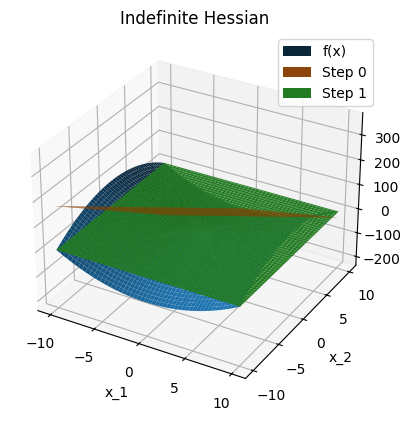

In [32]:
def f( x1: float, x2: float ) -> float:
    return x1 ** 2 - x2 ** 2

def f_d( x1: float, x2: float ) -> np.ndarray:
    return np.array( [2 * x1, -2 * x2] )

def f_dd( x1: float, x2: float ) -> np.ndarray:
    return np.array( [[2, 0], [0, -2]] )

plottable_funcs = newtons_method_2d_func_gen( f = f, f_d = f_d, f_dd = f_dd, x_0 = np.array( [5, 10] ) )
labels = [f"Step {l - 1}" for l, _ in enumerate(plottable_funcs) ]
labels[0] = "f(x)"

plot.plot_multivariate_functions( funcs = plottable_funcs, labels = labels, x_range = (-10, 10), title = "Indefinite Hessian" ).show()

#### Normal Distribution Transform

Definitions:
- $\vec{p}$:  the parameters to be estimated $\rightarrow (x, y, z, r_x, r_y, r_z)$
- $\textbf{x}$:  the $n \times 3$ matrix of points, $\vec{x}$, contained in the target (sensed) point cloud
- $\textbf{x}'$:  the $n \times 3$ matrix of points, $\vec{x}$ contained in the target point cloud after transformation via the parameters, $p$, where $\textbf{x}' = T(\textbf{x}, p)$
- $pr(\vec{x}_i')$:  the probability of a single point given the alignment, $p$
- $s$:  the total score, or sum of all $pr(\vec{x}_i)$
- $\textbf{y}$:  the $n \times 3$ matrix of points, $\vec{y}$, contained in the reference point cloud
- $\Sigma$:  the covariance of $\textbf{y}$
- $\vec{\mu}$:  the mean of $\textbf{y}$

The normal distribution transform utilizes Newton's method to minimize the score of its cost function, $pr(\textbf{x}')$, by varying the parameters which, in the 3D case, are the translation components $(x, y, z)$ and Euler angles $(r_x, r_y, r_z)$. The cost function is a Gaussian approximation of the negative log likelihood function:

\begin{align*}
pr(\vec{x}) &= d_1 * exp( -\frac{d_2}{2}(\vec{x} - \vec{\mu})^T \Sigma^{-1} (\vec{x} - \vec{\mu}) ) \\\\
score &= - \Sigma_{i = 1}^n pr(\vec{x}_i)
\end{align*}

where

\begin{align*}
q &= \frac{1}{n} \Sigma_i x_i \\\\
\Sigma &= \frac{1}{n - 1} \Sigma_i (x_i - q)(x_i - q)^T
\end{align*}

Depending on the implementation, $d_1$ and $d_2$ can take many forms. In Peter Biber's initial implementation (2003), $d_1 = d_2 = 1$. In Zaganidis' semantically-assisted implementation (2018), $d_2 = 1$ and $d_1 = \frac{1}{\sqrt{(2 \pi)^3 |\Sigma|}}$. Magnusson's implementation is spelled out in equation 6.8 of his dissertation, where he attempts to emulate the mixed negative log-likelihood + uniform distribution function, but poorly defines solving for the constants, $c_1$ and $c_2$. Here, we will use Zaganidis' implementation, which improves the weighting of high-confidence areas over Biber's implementation. Zaganidis' implementation may stuggle more with noisy data due to this scaling. Therefore,

\begin{align*}
pr(\vec{x}) &= \frac{1}{\sqrt{(2 \pi)^3 |\Sigma|}} exp( -\frac{(\vec{x} - \vec{\mu})^T \Sigma^{-1} (\vec{x} - \vec{\mu})}{2} ) \\\\
s &= - \Sigma_{i = 1}^n pr(\vec{x}_i)
\end{align*}

In [33]:
class Voxel:
    def __init__( self, y: np.ndarray ):
        
        if( y.shape[0] < 5 ): 
            self.is_empty = True
            return
        
        else: self.is_empty = False

        if( y.shape[1] != 3 or y.ndim != 2 ):
            raise ValueError( f"y must be shape (N, 3), not {y.shape}" )

        self.mu = np.mean( y, axis = 0 )
        self.sigma = 1 / ( y.shape[0] - 1 ) * ( ( y - self.mu ).transpose() @ ( y - self.mu ) )
        self.info_matrix = np.linalg.inv( self.sigma )
        self.determinant = np.linalg.det( self.sigma )

    def get_score( self, x_i: np.ndarray ) -> float:

        if( self.is_empty ): return 0.0

        if( x_i.shape != (3, 1) ):
            raise ValueError( f"x_i must be shape (3, 1), not {x_i.shape}" )

        return ( 1 / np.sqrt( ( 2 * np.pi ) ** 3 * self.determinant ) ) * np.exp( -( ( x_i - self.mu ).transpose() @ self.info_matrix @ ( x_i - self.mu ) ) / 2 )


With the cost function defined, the next step is to compute the Jacobian and Hessian matrices for the optimization. Magnusson loosely refers to two different Jacobians and two different Hessians with inconsistent notation. The equations with consistent notation applied are spelled out below.

- $\textbf{J}_E$:  the first derivative of the rotation defined by the 6D parameter function, $\vec{p}$, defined in eq. 6.19-20 in Magnusson's dissertation
- $\textbf{H}_E$:  the second derivate of the rotation defined by the 6D parameter function, $\vec{p}$, defined in eq. 6.20-21 ub Magnusson's dissertation
- $\textbf{g}$:  the first derivative of the score function, $s$, defined in eq. 6.12 in Magnusson's dissertation
- $\textbf{H}$:  the second derivative of the score function, $s$, defined in eq. 6.13 in Magnusson's dissertation

$\textbf{J}_E$ and $\textbf{H}_E$ are computed per-point and used as $\frac{\delta \vec{x}'_k}{\delta p_i}$ and $\frac{\delta^2 \vec{x}'_k}{\delta p_i \delta p_j}$ in the equations for $g$ and $H$.

A damped implementation of Newton's Method and a Levenberg-Marquardt implementation are included in the `Optimization` class, both solving the 6D minization function equivalent to the 1D and 2D cases above:

\begin{align*}
\vec{p}_{n + 1} = \vec{p}_n - H^{-1}g
\end{align*}

In [34]:
class Parameters:
    def __init__( self, se3: np.ndarray ):

        assert se3.ndim == 2, f"se3 must be a 4x4 np.ndarray, not ${se3.shape}$"
        assert se3.shape[0] == 4, f"se3 must be a 4x4 np.ndarray, not ${se3.shape}$"
        assert se3.shape[1] == 4, f"se3 must be a 4x4 np.ndarray, not ${se3.shape}$"

        euler_angles: dict[str, float] = mat.get_roll_pitch_yaw_deg( se3 )

        self.se3 = se3

        self.x = se3[3, 0]
        self.y = se3[3, 1]
        self.z = se3[3, 2]
        self.r_x = np.deg2rad( euler_angles['roll'] )
        self.r_y = np.deg2rad( euler_angles['pitch'] )
        self.r_z = np.deg2rad( euler_angles['yaw'] )

        self.cx = np.cos( self.r_x )
        self.sx = np.sin( self.r_x )

        self.cy = np.cos( self.r_y )
        self.sy = np.sin( self.r_y )

        self.cz = np.cos( self.r_z )
        self.sz = np.sin( self.r_z )

        self.vec6 = np.array( [self.x, self.y, self.z, self.r_x, self.r_y, self.r_z] ).reshape(( 6, 1 ))

    def __call__( self ) -> np.ndarray:
        return self.vec6
    
    def update( self, vec6: np.ndarray ) -> None:

        self.vec6 = vec6.copy()

        self.x = self.vec6[0]
        self.y = self.vec6[1]
        self.z = self.vec6[2]
        self.r_x = self.vec6[3]
        self.r_y = self.vec6[4]
        self.r_z = self.vec6[5]

        self.cx = np.cos( self.r_x )
        self.sx = np.sin( self.r_x )

        self.cy = np.cos( self.r_y )
        self.sy = np.sin( self.r_y )

        self.cz = np.cos( self.r_z )
        self.sz = np.sin( self.r_z )

In [35]:
class Point:
    def __init__( self, pos: np.ndarray, v: Voxel ):

        assert pos.shape == (3, 1), f"x_i must have shape (3, 1), not {pos.shape}"

        self.pos = pos
        self.voxel = v
    
    def __call__( self ) -> np.ndarray:
        return self.pos
    
    def is_contained_by( self ) -> Voxel:
        return self.voxel
    
    def transform( self, delta_vec6: np.ndarray ) -> None:

        assert delta_vec6.shape == (6, 1), f"delta_vec6 must be shape (6, 1) of (x, y, z, r_x, r_y, r_z), not {delta_vec6.shape}"

        R = mat.get_dcm( np.rad2deg( delta_vec6[3] ), np.rad2deg( delta_vec6[4] ), np.rad2deg( delta_vec6[5] ) )
        self.pos = R @ self.pos + delta_vec6[:3]

In [36]:
class ReferencePointCloud:
    def __init__( self, y: np.ndarray ):

        assert y.ndim == 2, f"y must be an (n, 3) vector of points, not {y.shape}"
        assert y.shape[1] == 3, f"y must be an (n, 3) vector of points, not {y.shape}"

        # For ease, divide into 8 voxels
        _max = np.array( [ np.max( y[:, 0] ), np.max( y[:, 1] ), np.max( y[:, 2] ) ] )
        _min = np.array( [ np.min( y[:, 0] ), np.min( y[:, 1] ), np.min( y[:, 2] ) ] )
        self._mid = np.array( ( _max + _min ) / 2 )

        y_div: list[list[np.ndarray]] = [[], [], [], [], [], [], [], []]

        for pt in y:

            y_div[self.get_voxel_idx( pt )].append( pt )
        
        self.voxels: list[Voxel] = []
        self.y: list[np.ndarray] = []
        for div in y_div:
            self.y.append( np.array( div ) )
            self.voxels.append( Voxel( np.array( div ) ) )

    def get_voxel_list( self ) -> list[Voxel]:
        return self.voxels
    
    def get_voxel( self, pt: np.ndarray ) -> Voxel:

        assert pt.shape == (3,) or pt.shape == (3, 1), f"pt shape must be (3,) or (3, 1), not {pt.shape}"

        return self.voxels[self.get_voxel_idx( pt )]
    
    def get_pc_list( self ) -> list[np.ndarray]:
        return self.y
    
    def get_pc( self, idx: int ):
        return self.y[idx]
    
    def get_voxel_idx( self, pt: np.ndarray ) -> int:

        assert pt.shape == (3,) or pt.shape == (3, 1), f"pt shape must be (3,) or (3, 1), not {pt.shape}"

        if( pt[0] <= self._mid[0] and pt[1] <= self._mid[1] and pt[2] <= self._mid[2] ):
            return 0

        elif( pt[0] <= self._mid[0] and pt[1] <= self._mid[1] and pt[2] > self._mid[2]):
            return 1

        elif( pt[0] <= self._mid[0] and pt[1] > self._mid[1] and pt[2] <= self._mid[2]):
            return 2

        elif( pt[0] <= self._mid[0] and pt[1] > self._mid[1] and pt[2] > self._mid[2]):
            return 3

        elif( pt[0] > self._mid[0] and pt[1] <= self._mid[1] and pt[2] <= self._mid[2]):
            return 4

        elif( pt[0] > self._mid[0] and pt[1] <= self._mid[1] and pt[2] > self._mid[2]):
            return 5

        elif( pt[0] > self._mid[0] and pt[1] > self._mid[1] and pt[2] <= self._mid[2]):
            return 6

        else:
            return 7

In [37]:
class TargetPointCloud:
    def __init__( self, p: Parameters ):

        self.p: Parameters = p
        self.points: list[Point] = []

    def __call__( self ) -> Parameters: 
        return self.p
    
    def get_points( self ) -> list[Point]:
        return self.points
    
    def add( self, pt: Point ):
        self.points.append( pt )

    def transform( self, delta_vec6: np.ndarray ):

        for pt in self.points:
            pt.transform( delta_vec6 )

    def J_E( self, pt: Point ) -> np.ndarray:

        x_i = pt()
        p = self.p

        a = x_i[0] * ( -p.sx * p.sz + p.cx * p.sy * p.cz )  + x_i[1] * ( -p.sx * p.cz - p.cx * p.sy * p.sz )    + x_i[2] * ( -p.cx * p.cy )
        b = x_i[0] * ( p.cx * p.sz + p.sx * p.sy * p.cz )   + x_i[1] * ( -p.sx * p.sy * p.sz + p.cx * p.cz )    + x_i[2] * ( -p.sx * p.cy )
        c = x_i[0] * ( -p.sy * p.cz )                       + x_i[1] * ( p.sy * p.sz )                          + x_i[2] * ( p.cy )
        d = x_i[0] * ( p.sx * p.cy * p.cz )                 + x_i[1] * ( -p.sx * p.cy * p.sz )                  + x_i[2] * ( p.sx * p.sy )
        e = x_i[0] * ( -p.cx * p.cy * p.cz )                + x_i[1] * ( p.cx * p.cy * p.sz )                   + x_i[2] * ( -p.cx * p.sy )
        f = x_i[0] * ( -p.cy * p.sz )                       + x_i[1] * ( -p.cy * p.cz )
        g = x_i[0] * ( p.cx * p.cz - p.sx * p.sy * p.sz )   + x_i[1] * ( -p.cx * p.sz - p.sx * p.sy * p.cz )
        h = x_i[0] * ( p.sx * p.cz + p.cx * p.sy * p.sz )   + x_i[1] * ( p.cx * p.sy * p.cz - p.sx * p.sz )

        return np.array(
            [[1,    0,  0,  0,  c,  f], 
             [0,    1,  0,  a,  d,  g], 
             [0,    0,  1,  b,  e,  h]]
        )
    
    def H_E( self, pt: Point ) -> np.ndarray:

        x_i = pt()
        p = self.p

        a = np.array(
            [
                0,
                x_i[0] * ( -p.cx * p.sz - p.sx * p.sy * p.cz )  + x_i[1] * ( -p.cx * p.cz + p.sx * p.sy * p.sz )    + x_i[2] * ( p.sx * p.cy ),
                x_i[0] * ( -p.sx * p.sz + p.cx * p.sy * p.cz )  + x_i[1] * ( -p.cx * p.sy * p.sz - p.sx * p.cz )    + x_i[2] * ( -p.cx * p.cy )
            ]
        )

        b = np.array(
            [
                0,
                x_i[0] * ( p.cx * p.cy * p.cz )                 + x_i[1] * ( -p.cx * p.cy * p.sz )                  + x_i[2] * ( p.cx * p.sy ),
                x_i[0] * ( p.sx * p.cy * p.cz )                 + x_i[1] * ( -p.sx * p.cy * p.sz )                  + x_i[2] * ( p.sx * p.sy )
            ]
        )

        c = np.array(
            [
                0,
                x_i[0] * ( -p.sx * p.cz - p.cx * p.sy * p.sz )  + x_i[1] * ( -p.sx * p.sz - p.cx * p.sy * p.cz ),
                x_i[0] * ( p.cx * p.cz - p.sx * p.sy * p.sz )   + x_i[1] * ( -p.sx * p.sy * p.cz - p.cx * p.sz ),
            ]
        )

        d = np.array(
            [
                x_i[0] * ( -p.cy * p.cz )                       + x_i[1] * ( p.cy * p.sz )                          + x_i[2] * ( -p.sy ),
                x_i[0] * ( -p.sx * p.sy * p.cz )                + x_i[1] * ( p.sx * p.sy * p.sz )                   + x_i[2] * ( p.sx * p.cy ),
                x_i[0] * ( p.cx * p.sy * p.cz )                 + x_i[1] * ( -p.cx * p.sy * p.sz )                  + x_i[2] * ( -p.cx * p.cy ),
            ]
        )

        e = np.array(
            [
                x_i[0] * ( p.sy * p.sz )                        + x_i[1] * ( p.sy * p.cz ),
                x_i[0] * ( -p.sx * p.cy * p.sz )                + x_i[1] * ( -p.sx * p.cy * p.cz ),
                x_i[0] * ( p.cx * p.cy * p.sz )                 + x_i[1] * ( p.cx * p.cy * p.cz ),
            ]
        )

        f = np.array(
            [
                x_i[0] * ( -p.cy * p.cz )                       + x_i[1] * ( p.cy * p.sz ),
                x_i[0] * ( -p.cx * p.sz - p.sx * p.sy * p.cz )  + x_i[1] * ( -p.cx * p.cz + p.sx * p.sy * p.sz ),
                x_i[0] * ( -p.sx * p.sz + p.cx * p.sy * p.cz )  + x_i[1] * ( -p.cx * p.sy * p.sz - p.sx * p.cz ),
            ]
        )


        return np.array([
            [np.zeros((3,)),    np.zeros((3,)), np.zeros((3,)), np.zeros((3,)), np.zeros((3,)), np.zeros((3,))  ],
            [np.zeros((3,)),    np.zeros((3,)), np.zeros((3,)), np.zeros((3,)), np.zeros((3,)), np.zeros((3,))  ],
            [np.zeros((3,)),    np.zeros((3,)), np.zeros((3,)), np.zeros((3,)), np.zeros((3,)), np.zeros((3,))  ],
            [np.zeros((3,)),    np.zeros((3,)), np.zeros((3,)), a,              b,              c               ],
            [np.zeros((3,)),    np.zeros((3,)), np.zeros((3,)), b,              d,              e               ],
            [np.zeros((3,)),    np.zeros((3,)), np.zeros((3,)), c,              e,              f               ]
        ])

In [38]:
class Optimization:
    def __init__( self, v: Callable[[np.ndarray], Voxel] ):

        self.v: Callable[[np.ndarray], Voxel] = v

    # def newtons_method( self, initial_se3: np.ndarray, epsilon: float = 0.001, max_iterations: int = 10 ):

        # delta_f: float = epsilon * 10
        # p_k: np.ndarray = initial_se3

        # ps: list[ np.ndarray ] = [ initial_se3 ]
        
        # while( delta_f > epsilon ):
        #     m = f_d( x )
        #     b = f( x ) - m * x

        #     f_n.append( lambda x_n, m = m, b = b: m * x_n + b )

        #     f_xn_1 = f( x )
        #     x = x - f_d( x ) / f_dd( x )
        #     f_xn = f( x)

        #     delta_f = abs( f_xn - f_xn_1 )

        # print( f"Minima found at x = {x}" )

        # return f_n

    def f( self, x_i: np.ndarray ) -> float:

        assert x_i.ndim == 2, f"x_i must have shape (3, 1), not {x_i.shape}"
        assert x_i.shape == (3, 1), f"x_i must have shape (3, 1), not {x_i.shape}"

        return self.v( x_i ).get_score( x_i )
    
    def f_d( self, x_i: np.ndarray, p: Parameters ) -> np.ndarray:
        return np.zeros(1)
    
    def f_dd( self, x_i: np.ndarray, p: Parameters ) -> np.ndarray:
        return np.zeros(1)
    
    def __validate_H( self, H: np.ndarray, damp: bool = False ) -> bool:

        if( H.ndim != 2 or H.shape[0] != H.shape[1] ):
            print( f"Hessian must be a square, 2D matrix, not {H.shape}. Escaping..." )
            return False

        # Check for singularity
        if( np.isclose( np.linalg.det( H ), 0 ) ):
            print( "Hessian is singular and non-invertable. Escaping..." )
            return False
        
        # Damp as needed
        
        return False

In [39]:
mesh = ms.MeshSampler( 'mesh/a10_meshDecimated.obj', 'A-10', rotation_matrix = np.array( [[1, 0, 0], [0, 0, 1], [0, 1, 0]] ) )
mesh.show_mesh()

In [ ]:
initial_R = mat.get_dcm( 0, 0, 0 )
inital_t = np.array( [0, 0, 0] ).reshape( (3, 1) )

se3 = np.eye(4)

se3[:3, :3] = initial_R
se3[:3, 3:] = inital_t

p = Parameters( se3 = se3 )
target_pc = TargetPointCloud( p )

if( mesh.mesh is not None ):  

    # Intialize reference point cloud
    ref_pc = ReferencePointCloud( y = np.asarray( mesh.mesh.vertices ) )
    pc_list = ref_pc.get_pc_list()
    mesh.display_point_clouds( pc_list, [f"Voxel {i}" for i in range( len( pc_list ) )], "Voxelized Reference Point Cloud" )

    # Initialize target point cloud
    obs, lbls, pos, dcm = mesh.create_full_sample_observations( n = 1, p = 300, pad = 1000 )
    obs = obs.squeeze( axis = 0 )
    mesh.display_point_clouds( [ obs ], list( lbls ), "Target Point Cloud" )

    pts: list[Point] = []
    for pt in obs:
        pts.append( Point( pt.reshape( ( 3, 1 ) ), ref_pc.get_voxel( pt.reshape( ( 3, 1 ) ) ) ) )
        target_pc.add( pts[-1] )

AssertionError: x_i must have shape (3, 1), not (3,)